# Fire Fighting Robot - Decision Tree Classifier

Notebook ini disusun mengikuti metodologi data science yang dipakai di materi kuliah: business understanding, analytic approach, data understanding, data preparation, feature engineering, modeling, evaluation, dan deployment.

Kasus yang dikerjakan adalah klasifikasi arah api pada robot pemadam api berbasis lima nilai flame sensor Arduino.

## 1. Business Understanding

**Problem:** robot pemadam api awal sudah dapat bergerak berdasarkan flame sensor, tetapi logika keputusan masih berbasis threshold manual dan servo nozzle masih bergerak sweeping, belum mengikuti arah api secara adaptif.

**Tujuan proyek:** membuat model machine learning sederhana yang dapat mengklasifikasikan arah api dari pembacaan sensor, kemudian hasil klasifikasi digunakan untuk mengatur arah gerak robot dan arah servo nozzle. Deteksi jarak dekat (proximity) dipertahankan sebagai threshold deterministik pada channel tengah, terpisah dari model ML.

**Indikator keberhasilan:** model dapat memprediksi kelas `NO_FIRE`, `FIRE_LEFT`, `FIRE_CENTER`, dan `FIRE_RIGHT`, lalu aturan model dapat diekspor ke kode Arduino sebagai fungsi `if-else`.

## 2. Analytic Approach

Pendekatan analitik yang digunakan adalah **supervised learning** dengan tipe masalah **classification**.

Algoritma yang digunakan hanya **Decision Tree Classifier** karena:
- data input berupa nilai numerik sensor,
- output berupa kelas kondisi api,
- model mudah dijelaskan,
- hasil model dapat diubah menjadi kode `if-else` untuk Arduino.

## 3. Data Requirement dan Data Collection

Data yang dibutuhkan adalah pembacaan analog dari flame sensor Arduino A5 sampai A1. Pada dataset, kelima pembacaan ini diberi nama `s1` sampai `s5`.

Mapping fitur:
- `s1` = A5
- `s2` = A4
- `s3` = A3
- `s4` = A2
- `s5` = A1

Setiap baris data harus diberi label sesuai posisi atau kondisi api. Untuk progres awal, notebook menggunakan dummy dataset. Setelah pengujian lab, dummy dataset diganti dengan data asli dari Serial Monitor Arduino.

## 4. Setup Environment

In [1]:
%pip install pandas scikit-learn matplotlib

/nix/store/8cc0zyvfzg3dj029pzl8v0372n52xfmi-python3-3.13.12-env/bin/python3.13: No module named pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree

## 5. Data Understanding

Pada tahap ini dataset dibaca, jumlah data dicek, distribusi label dilihat, dan karakteristik nilai sensor diperiksa. Tujuannya untuk memahami apakah data sudah sesuai dengan kebutuhan klasifikasi.

In [3]:
dataset_path = '../data/dummy_dataset_fire_robot.csv'

df = pd.read_csv(dataset_path)
df.head()

,s1,s2,s3,s4,s5,label
0,930,910,900,920,940,NO_FIRE
1,920,935,910,905,925,NO_FIRE
2,890,900,880,910,905,NO_FIRE
3,860,830,780,820,850,NO_FIRE
4,760,720,330,730,750,NO_FIRE


In [4]:
print('Jumlah baris dan kolom:', df.shape)
print('Kolom:', list(df.columns))
df['label'].value_counts()

Jumlah baris dan kolom: (100, 6)
Kolom: ['s1', 's2', 's3', 's4', 's5', 'label']


label
NO_FIRE        20
FIRE_LEFT      20
FIRE_CENTER    20
FIRE_RIGHT     20
FIRE_CLOSE     20
Name: count, dtype: int64

In [5]:
df.describe()

,s1,s2,s3,s4,s5
count,100.000000,100.000000,100.000000,100.000000,100.000000
mean,840.050000,711.950000,667.850000,718.150000,837.550000
std,52.370547,169.125641,196.192617,166.332476,49.825428
min,720.000000,300.000000,300.000000,310.000000,710.000000
25%,805.000000,693.750000,527.500000,697.500000,803.750000
50%,845.000000,767.500000,672.500000,780.000000,840.000000
75%,880.000000,821.250000,862.500000,821.250000,871.250000
max,940.000000,935.000000,990.000000,920.000000,940.000000


## 6. Data Preparation

Tahap ini memastikan data siap dipakai model. Pengecekan yang dilakukan:
- memastikan kolom fitur dan label tersedia,
- mengecek missing value,
- mengecek duplikasi data,
- memastikan semua fitur sensor bertipe numerik,
- memisahkan fitur (`X`) dan label (`y`).

In [6]:
FEATURES = ['s1', 's2', 's3', 's4', 's5']
TARGET = 'label'

required_columns = FEATURES + [TARGET]
missing_columns = [col for col in required_columns if col not in df.columns]
if missing_columns:
    raise ValueError(f'Kolom belum lengkap: {missing_columns}')

print('Missing value per kolom:')
print(df[required_columns].isna().sum())
print('Jumlah duplikasi:', df.duplicated().sum())

Missing value per kolom:
s1       0
s2       0
s3       0
s4       0
s5       0
label    0
dtype: int64
Jumlah duplikasi: 0


In [7]:
df_clean = df[required_columns].dropna().drop_duplicates().copy()

for feature in FEATURES:
    df_clean[feature] = pd.to_numeric(df_clean[feature])

X = df_clean[FEATURES]
y = df_clean[TARGET]

print('Dataset setelah cleaning:', df_clean.shape)
df_clean.head()

Dataset setelah cleaning: (100, 6)


,s1,s2,s3,s4,s5,label
0,930,910,900,920,940,NO_FIRE
1,920,935,910,905,925,NO_FIRE
2,890,900,880,910,905,NO_FIRE
3,860,830,780,820,850,NO_FIRE
4,760,720,330,730,750,NO_FIRE


## 7. Feature Engineering

Fitur utama tetap menggunakan `s1` sampai `s5` agar mudah dipindahkan ke Arduino. Pada tahap analisis, kita juga membuat fitur bantu untuk memahami pola data, misalnya sensor terkuat dan nilai maksimum.

Fitur bantu ini tidak wajib dipakai pada model final, tetapi berguna untuk menjelaskan pola sensor pada laporan.

In [8]:
analysis_df = df_clean.copy()
analysis_df['max_sensor_value'] = analysis_df[FEATURES].max(axis=1)
analysis_df['strongest_sensor'] = analysis_df[FEATURES].idxmax(axis=1)
analysis_df[['s1', 's2', 's3', 's4', 's5', 'max_sensor_value', 'strongest_sensor', 'label']].head()

,s1,s2,s3,s4,s5,max_sensor_value,strongest_sensor,label
0,930,910,900,920,940,940,s5,NO_FIRE
1,920,935,910,905,925,935,s2,NO_FIRE
2,890,900,880,910,905,910,s4,NO_FIRE
3,860,830,780,820,850,860,s1,NO_FIRE
4,760,720,330,730,750,760,s1,NO_FIRE


In [9]:
pd.crosstab(analysis_df['strongest_sensor'], analysis_df['label'])

label,FIRE_CENTER,FIRE_CLOSE,FIRE_LEFT,FIRE_RIGHT,NO_FIRE
strongest_sensor,,,,,
s1,20,0,20,0,15
s2,0,0,0,0,1
s3,0,20,0,0,0
s4,0,0,0,0,1
s5,0,0,0,20,3


## 8. Modeling Scenario

Skenario pemodelan menggunakan pembagian data training dan testing dengan rasio **80:20** (stratified), memastikan setiap kelas terwakili secara proporsional di kedua partisi.

Model yang digunakan adalah `DecisionTreeClassifier` dengan `max_depth=4` agar aturan tidak terlalu panjang saat diekspor ke Arduino.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print('Training data:', X_train.shape)
print('Testing data:', X_test.shape)

In [11]:
tree_model = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)
accuracy = accuracy_score(y_test, tree_pred)
print(f'Decision Tree Accuracy: {accuracy:.3f}')

Decision Tree Accuracy: 0.920


## 9. Evaluation

Evaluasi menggunakan metrik klasifikasi dari materi membangun model, yaitu accuracy, precision, recall, f1-score, dan confusion matrix.

              precision    recall  f1-score   support

 FIRE_CENTER       0.71      1.00      0.83         5
  FIRE_CLOSE       1.00      0.80      0.89         5
   FIRE_LEFT       1.00      1.00      1.00         5
  FIRE_RIGHT       1.00      1.00      1.00         5
     NO_FIRE       1.00      0.80      0.89         5

    accuracy                           0.92        25
   macro avg       0.94      0.92      0.92        25
weighted avg       0.94      0.92      0.92        25



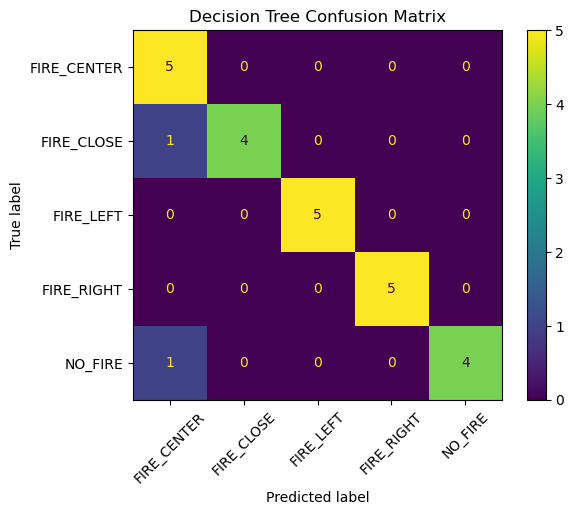

In [12]:
print(classification_report(y_test, tree_pred))

labels = list(tree_model.classes_)
cm = confusion_matrix(y_test, tree_pred, labels=labels)
ConfusionMatrixDisplay(cm, display_labels=labels).plot(xticks_rotation=45)
plt.title('Decision Tree Confusion Matrix')
plt.show()

## 10. Model Interpretation

Decision Tree dipilih karena aturan keputusannya dapat dibaca. Bagian ini menampilkan aturan teks dan visualisasi pohon keputusan untuk menjelaskan cara model mengambil keputusan.

In [13]:
print(export_text(tree_model, feature_names=FEATURES))

|--- s4 <= 595.00
|   |--- class: FIRE_RIGHT
|--- s4 >  595.00
|   |--- s2 <= 590.00
|   |   |--- class: FIRE_LEFT
|   |--- s2 >  590.00
|   |   |--- s3 <= 877.50
|   |   |   |--- s2 <= 797.50
|   |   |   |   |--- class: FIRE_CENTER
|   |   |   |--- s2 >  797.50
|   |   |   |   |--- class: NO_FIRE
|   |   |--- s3 >  877.50
|   |   |   |--- s2 <= 882.50
|   |   |   |   |--- class: FIRE_CLOSE
|   |   |   |--- s2 >  882.50
|   |   |   |   |--- class: NO_FIRE



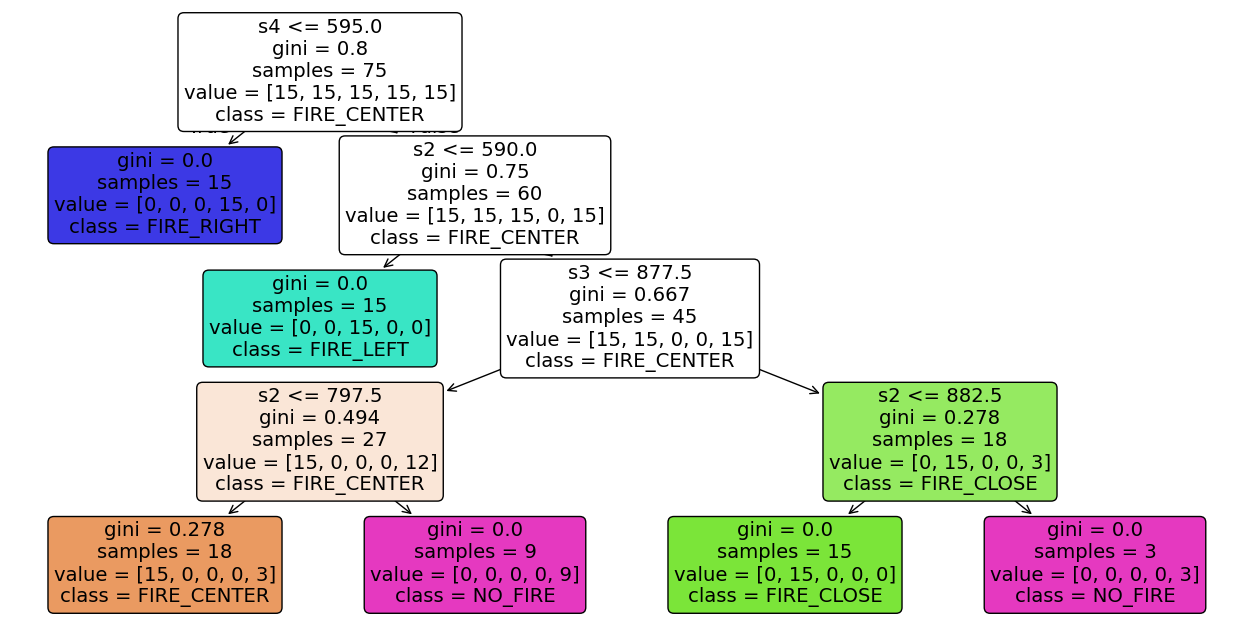

In [14]:
plt.figure(figsize=(16, 8))
plot_tree(
    tree_model,
    feature_names=FEATURES,
    class_names=tree_model.classes_,
    filled=True,
    rounded=True
)
plt.show()

## 11. Deployment ke Arduino

Tahap deployment dilakukan dengan mengubah Decision Tree menjadi fungsi `predictFireDirection()` dalam bahasa C++ Arduino. Fungsi ini kemudian ditempelkan ke file `02_fire_robot_ml.ino`.

In [ ]:
LABEL_TO_CODE = {
    'NO_FIRE':     0,
    'FIRE_LEFT':   1,
    'FIRE_CENTER': 2,
    'FIRE_RIGHT':  3,
}

def arduino_tree(node, tree, feature_names, class_names, indent='  '):
    left = tree.children_left[node]
    right = tree.children_right[node]

    if left == right:
        class_index = tree.value[node][0].argmax()
        return f'{indent}return {class_names[class_index]};\n'

    feature = feature_names[tree.feature[node]]
    threshold = int(round(tree.threshold[node]))

    code = f'{indent}if ({feature} <= {threshold}) {{\n'
    code += arduino_tree(left, tree, feature_names, class_names, indent + '  ')
    code += f'{indent}}} else {{\n'
    code += arduino_tree(right, tree, feature_names, class_names, indent + '  ')
    code += f'{indent}}}\n'
    return code

class_names = list(tree_model.classes_)

print('enum FireDirection {')
for label, code in LABEL_TO_CODE.items():
    print(f'  {label} = {code},')
print('};')

print('\nint predictFireDirection(int s1, int s2, int s3, int s4, int s5) {')
print(arduino_tree(0, tree_model.tree_, FEATURES, class_names), end='')
print('}')

## 12. Testing Prediksi Manual

Cell ini digunakan untuk memasukkan nilai sensor dari Serial Monitor dan melihat prediksi model sebelum aturan dipasang ke Arduino.

In [16]:
sample = pd.DataFrame([{
    's1': 850,
    's2': 780,
    's3': 320,
    's4': 790,
    's5': 850,
}])

tree_model.predict(sample)[0]

'FIRE_CENTER'

## 13. Panduan Pengambilan Data Asli

Upload `arduino/01_sensor_logger/01_sensor_logger.ino` ke robot, buka Serial Monitor 9600 baud.

Output akan muncul dalam format:
```
s1,s2,s3,s4,s5
930,910,900,920,940
...
```

Ambil data per sesi kondisi api, lalu tambahkan kolom `label` secara manual:

```csv
s1,s2,s3,s4,s5,label
930,910,900,920,940,NO_FIRE
320,460,850,890,900,FIRE_LEFT
750,720,320,730,760,FIRE_CENTER
900,890,850,460,320,FIRE_RIGHT
```

**Target minimal data per kelas:**
- `NO_FIRE`: 30-50 baris (termasuk kondisi cahaya ambient / lampu ruangan)
- `FIRE_LEFT`: 30-50 baris (api di depan A5 atau A4, berbagai jarak)
- `FIRE_CENTER`: 30-50 baris (api sejajar A3, berbagai jarak)
- `FIRE_RIGHT`: 30-50 baris (api di depan A2 atau A1, berbagai jarak)

Simpan sebagai `data/fire_dataset_real.csv`, lalu ganti `dataset_path` di cell 5 dan jalankan ulang semua cell. Salin fungsi `predictFireDirection()` hasil training ke `arduino/02_fire_robot_ml/02_fire_robot_ml.ino`.